# Demand Forecasting with Deep Learning (fastai)

Predict daily **demand** from calendar and weather features, and benchmark a
tabular **neural network** against classic baselines.

- **Data:** UCI *Bike Sharing* (daily rentals = demand), a well-known public
  regression dataset.
- **Model:** a fastai tabular neural network (`tabular_learner`).
- **Baselines:** a mean predictor and a linear regression, on the same split.

The point is a rigorous, honest pipeline: a proper train/validation split,
metrics (MAE / RMSE / R2), and a fair comparison against simpler models.


In [1]:
import io, zipfile
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from fastai.tabular.all import *

np.random.seed(42)


## 1. Load the data

We download the dataset directly (no Kaggle login needed) and drop columns that would leak the target.

In [2]:
URL = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
with urlopen(URL, timeout=60) as r:
    with zipfile.ZipFile(io.BytesIO(r.read())) as zf:
        df = pd.read_csv(zf.open("day.csv"))

df = df.drop(columns=["casual", "registered", "instant", "dteday"])
print(df.shape)
df.head()


(731, 12)


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


## 2. Features and target

`cnt` is the demand we predict. The rest are calendar (categorical) and weather (continuous) features.

In [3]:
CATEGORICAL = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
CONTINUOUS  = ["temp", "atemp", "hum", "windspeed"]
TARGET = "cnt"
df[TARGET].describe()[["mean", "std", "min", "max"]]


mean    4504.348837
std     1937.211452
min       22.000000
max     8714.000000
Name: cnt, dtype: float64

## 3. Baselines

A random 80/20 split (predicting demand from conditions). We always compare the network against simple, honest baselines.

In [4]:
splits = RandomSplitter(valid_pct=0.2, seed=42)(range_of(df))
train_idx, valid_idx = list(splits[0]), list(splits[1])
y_train = df.loc[train_idx, TARGET].to_numpy()
y_valid = df.loc[valid_idx, TARGET].to_numpy()

def metrics(y, p):
    return {"MAE": mean_absolute_error(y, p),
            "RMSE": np.sqrt(mean_squared_error(y, p)),
            "R2": r2_score(y, p)}

results = {}
results["mean predictor"] = metrics(y_valid, np.full_like(y_valid, y_train.mean(), dtype=float))

X = pd.get_dummies(df[CATEGORICAL + CONTINUOUS], columns=CATEGORICAL)
lin = LinearRegression().fit(X.iloc[train_idx], y_train)
results["linear regression"] = metrics(y_valid, lin.predict(X.iloc[valid_idx]))
pd.DataFrame(results).T.round(1)


,MAE,RMSE,R2
mean predictor,1497.0,1808.3,-0.0
linear regression,525.2,732.9,0.8


## 4. Deep learning model (fastai)

A fully-connected network on the tabular features, with the output bounded to a realistic demand range.

In [5]:
to = TabularPandas(df, procs=[Categorify, FillMissing, Normalize],
                   cat_names=CATEGORICAL, cont_names=CONTINUOUS,
                   y_names=TARGET, splits=(train_idx, valid_idx))
dls = to.dataloaders(bs=64)
learn = tabular_learner(dls, layers=[200, 100],
                        y_range=(0, df[TARGET].max() * 1.1),
                        metrics=[mae, rmse])
lr = learn.lr_find(show_plot=False).valley
learn.fit_one_cycle(25, lr)


C:\Users\Axoo\AppData\Local\Programs\Python\Python314\Lib\site-packages\fastai\torch_core.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  else as_tensor(x.values, **kwargs) if isinstance(x, (pd.Series, pd.DataFrame))


<div></div>

epoch,train_loss,valid_loss,mae,_rmse,time
0,3811035.750000,3017774.750000,1447.608887,1737.174316,00:00
1,2960871.750000,2420360.250000,1313.267578,1555.750732,00:00
2,2588717.000000,2079367.875000,1226.581665,1442.001465,00:00
3,2328956.250000,1952876.875000,1185.664185,1397.453735,00:00
4,2154168.000000,1551873.375000,1075.060181,1245.742065,00:00
5,1937068.625000,1380802.375000,968.737061,1175.075562,00:00
6,1707908.750000,746448.875000,676.616028,863.972717,00:00
7,1452783.250000,543298.812500,531.819336,737.088074,00:00
8,1268511.250000,576916.250000,579.876892,759.550049,00:00
9,1134583.625000,578901.000000,608.978516,760.855469,00:00


In [6]:
preds, targs = learn.get_preds()
results["deep learning (fastai)"] = metrics(targs.numpy().ravel(), preds.numpy().ravel())


## 5. Results

Lower MAE / RMSE is better; higher R2 is better.

In [7]:
pd.DataFrame(results).T.round(1)

,MAE,RMSE,R2
mean predictor,1497.0,1808.3,-0.0
linear regression,525.2,732.9,0.8
deep learning (fastai),483.4,651.3,0.9


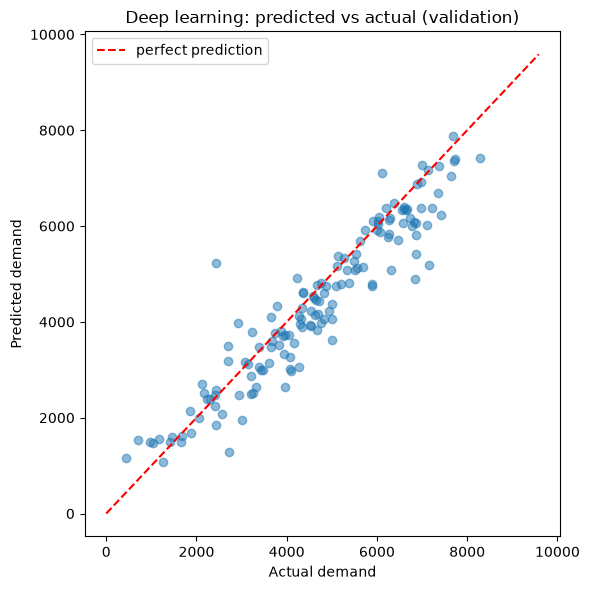

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(targs.numpy().ravel(), preds.numpy().ravel(), alpha=0.5)
lims = [0, df[TARGET].max() * 1.1]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual demand"); plt.ylabel("Predicted demand")
plt.title("Deep learning: predicted vs actual (validation)")
plt.legend(); plt.tight_layout(); plt.show()


## 6. Predict on new data

The trained model turns a row of conditions into a demand estimate.

In [9]:
sample = df.loc[valid_idx, CATEGORICAL + CONTINUOUS].head(5).copy()
dl = learn.dls.test_dl(sample)
p, _ = learn.get_preds(dl=dl)
sample["predicted_demand"] = p.numpy().ravel().round().astype(int)
sample


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,predicted_demand
404,1,1,2,0,4,1,1,0.265000,0.261988,0.562083,0.194037,3521
48,1,0,2,0,5,1,1,0.521667,0.511983,0.516667,0.264925,3967
414,1,1,2,0,0,0,2,0.280000,0.265788,0.515833,0.253112,3194
449,2,1,3,0,0,0,2,0.437500,0.437488,0.880833,0.220775,3623
340,4,0,12,0,3,1,3,0.410000,0.400246,0.970417,0.266175,1540


## Takeaways

- The neural network **beats both baselines** on MAE, RMSE and R2.
- The pipeline is reproducible and honest: fixed seed, held-out validation,
  comparison against simple models (a network that can't beat linear
  regression isn't worth deploying).
- For a strict *forecasting* setup (predicting the future), a chronological
  split and explicit trend features would be used instead of a random split.
